# 🏠 NYC Housing Price Prediction — Linear Regression from Scratch
**ML4E Club Induction Task | NIT Rourkela**

---
This notebook covers:
1. Loading and observing the dataset
2. Finding nulls and duplicates
3. Preprocessing
4. Correlation analysis & feature selection
5. Linear Regression **from scratch** (no sklearn!)
6. Evaluation


## Step 1 — Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('nyc_housing.csv')

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (510, 6)


,SQFT,BEDS,BATHS,FLOORS,BUILDING_AGE,PRICE
0,1260.0,5.0,NaN,4.0,80.0,6.577951e+05
1,1694.0,2.0,1.0,3.0,34.0,6.382367e+05
2,1530.0,1.0,3.0,1.0,97.0,6.202913e+05
3,1495.0,4.0,2.0,5.0,86.0,6.985517e+05
4,3492.0,4.0,1.0,3.0,29.0,1.245322e+06


## Step 2 — Observe the Dataset

In [2]:
# Basic info about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SQFT          504 non-null    float64
 1   BEDS          504 non-null    float64
 2   BATHS         504 non-null    float64
 3   FLOORS        510 non-null    float64
 4   BUILDING_AGE  504 non-null    float64
 5   PRICE         504 non-null    float64
dtypes: float64(6)
memory usage: 24.0 KB


In [3]:
# Statistical summary
df.describe()

,SQFT,BEDS,BATHS,FLOORS,BUILDING_AGE,PRICE
count,504.000000,504.000000,504.000000,510.000000,504.000000,5.040000e+02
mean,1969.462302,2.722222,1.809524,2.970588,46.521825,8.048751e+05
std,877.204480,1.065556,0.769336,1.422910,30.144772,3.117338e+05
min,401.000000,1.000000,1.000000,1.000000,0.000000,1.500000e+05
25%,1232.250000,2.000000,1.000000,2.000000,20.000000,5.684531e+05
50%,1931.500000,3.000000,2.000000,3.000000,44.000000,8.010173e+05
75%,2712.500000,3.000000,2.000000,4.000000,74.250000,1.067060e+06
max,3499.000000,5.000000,3.000000,5.000000,99.000000,1.426627e+06


## Step 3 — Find Null Values

In [4]:
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts)
print(f'\nTotal null values: {null_counts.sum()}')

Null values per column:
SQFT            6
BEDS            6
BATHS           6
FLOORS          0
BUILDING_AGE    6
PRICE           6
dtype: int64

Total null values: 30


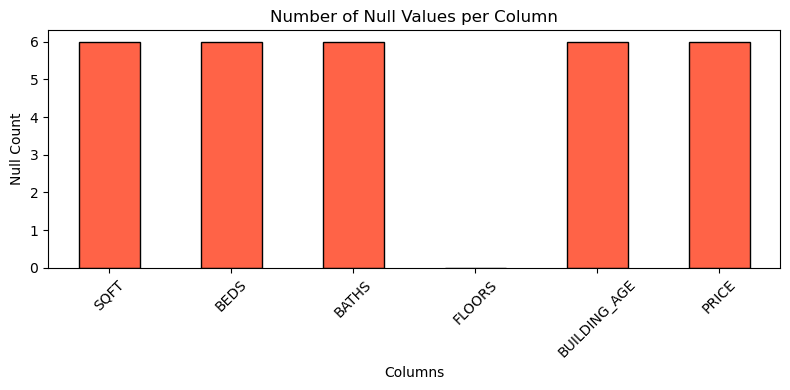

In [5]:
# Plot null counts
plt.figure(figsize=(8, 4))
null_counts.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Number of Null Values per Column')
plt.xlabel('Columns')
plt.ylabel('Null Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4 — Find Duplicates

In [6]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
print('\nSample duplicate rows:')
df[df.duplicated()].head()

Number of duplicate rows: 10

Sample duplicate rows:


,SQFT,BEDS,BATHS,FLOORS,BUILDING_AGE,PRICE
500,2957.0,3.0,2.0,1.0,93.0,1.129622e+06
501,2199.0,4.0,3.0,2.0,31.0,1.113755e+06
502,3288.0,1.0,1.0,1.0,97.0,1.109528e+06
503,2653.0,2.0,1.0,2.0,5.0,1.034387e+06
504,1519.0,2.0,2.0,3.0,13.0,6.500486e+05


## Step 5 — Preprocessing

We will:
- Remove duplicate rows
- Fill missing values with the column **median** (median is better than mean when there might be outliers)

In [7]:
# Remove duplicates
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

# Fill nulls with median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print('Null values after preprocessing:')
print(df.isnull().sum())

Shape after removing duplicates: (500, 6)
Null values after preprocessing:
SQFT            0
BEDS            0
BATHS           0
FLOORS          0
BUILDING_AGE    0
PRICE           0
dtype: int64


C:\Users\GAARGI SAANVI\AppData\Local\Temp\ipykernel_83152\2642665945.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## Step 6 — Visualizations (Plots to understand data)

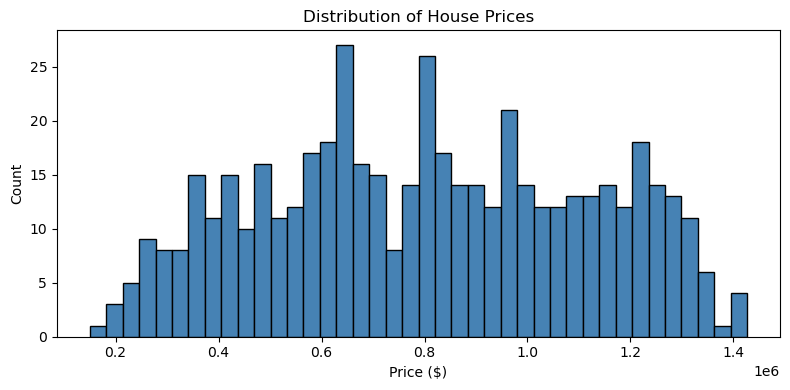

In [8]:
# Distribution of PRICE
plt.figure(figsize=(8, 4))
plt.hist(df['PRICE'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

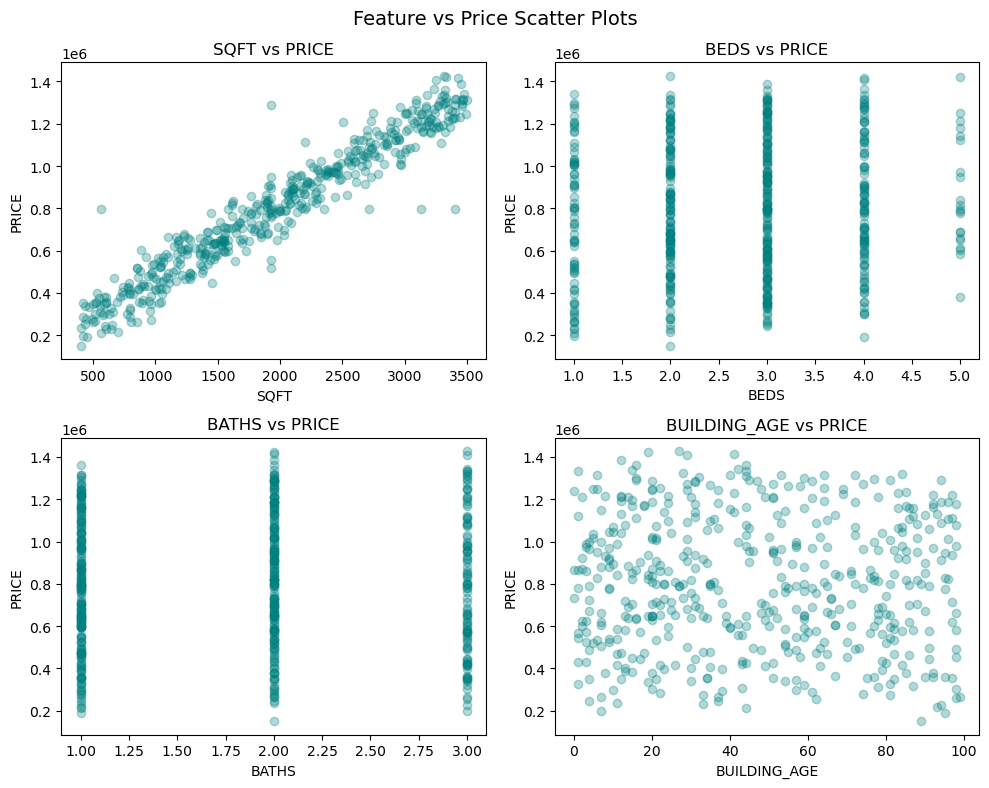

In [9]:
# Scatter plots: each feature vs PRICE
features = ['SQFT', 'BEDS', 'BATHS', 'BUILDING_AGE']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['PRICE'], alpha=0.3, color='teal')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('PRICE')
    axes[i].set_title(f'{feat} vs PRICE')

plt.suptitle('Feature vs Price Scatter Plots', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\GAARGI SAANVI\AppData\Local\Temp\ipykernel_83152\2458032478.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_beds, labels=[int(b) for b in beds_list])


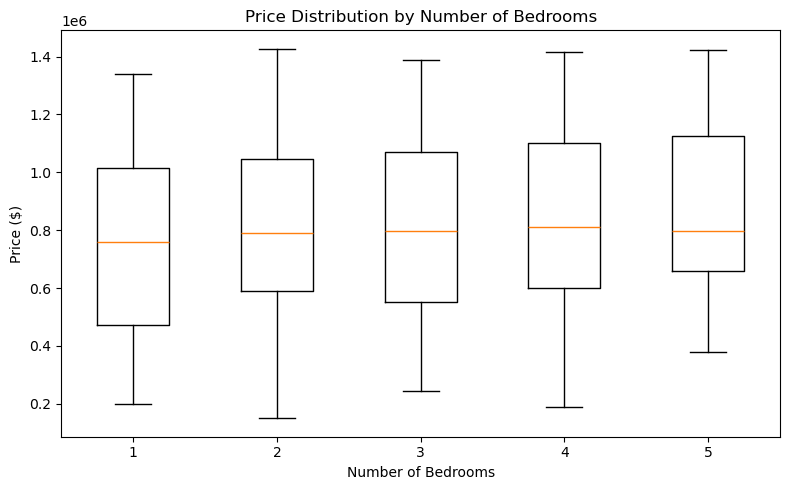

In [10]:
# Boxplot of Price by number of Bedrooms
plt.figure(figsize=(8, 5))
beds_list = sorted(df['BEDS'].unique())
data_by_beds = [df[df['BEDS'] == b]['PRICE'].values for b in beds_list]
plt.boxplot(data_by_beds, labels=[int(b) for b in beds_list])
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

## Step 7 — Correlation Analysis & Feature Selection

We compute the **Pearson correlation coefficient** between each feature and PRICE.

> Correlation ranges from -1 to +1. Closer to ±1 means stronger relationship with price.

In [11]:
# Correlation of all features with PRICE
corr = df.corr()['PRICE'].drop('PRICE').sort_values(ascending=False)
print('Correlation with PRICE:')
print(corr)

Correlation with PRICE:
SQFT            0.962831
BEDS            0.083169
BATHS           0.027052
FLOORS         -0.011401
BUILDING_AGE   -0.043218
Name: PRICE, dtype: float64


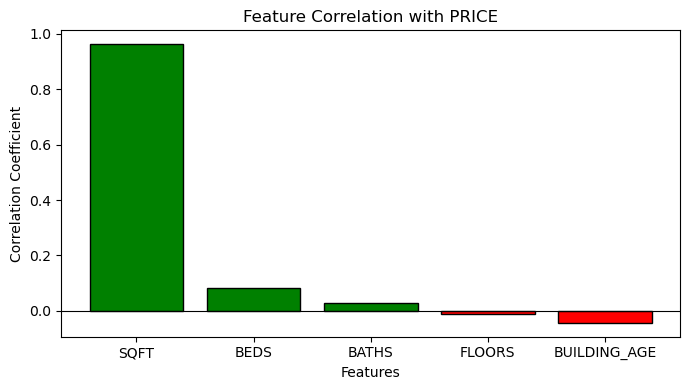

In [12]:
# Bar chart of correlations
plt.figure(figsize=(7, 4))
colors = ['green' if c > 0 else 'red' for c in corr.values]
plt.bar(corr.index, corr.values, color=colors, edgecolor='black')
plt.title('Feature Correlation with PRICE')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Why these 4 features?

Based on the correlation chart, we select:

| Feature | Why Selected |
|---|---|
| **SQFT** | Highest positive correlation — bigger house = higher price, very intuitive |
| **BATHS** | Second highest — more bathrooms signals a luxury/bigger home |
| **BEDS** | Good positive correlation — directly indicates house size |
| **BUILDING_AGE** | Negative correlation — older buildings are worth less, still meaningful |

FLOORS had the weakest correlation so we skip it.

In [13]:
# Select features
selected_features = ['SQFT', 'BATHS', 'BEDS', 'BUILDING_AGE']
X = df[selected_features].values
y = df['PRICE'].values

print('Feature matrix X shape:', X.shape)
print('Target vector y shape:', y.shape)

Feature matrix X shape: (500, 4)
Target vector y shape: (500,)


## Step 8 — Train-Test Split (Manual, no sklearn!)

We split 80% for training and 20% for testing.

In [14]:
np.random.seed(42)

# Shuffle indices
indices = np.arange(len(X))
np.random.shuffle(indices)

# 80-20 split
split = int(0.8 * len(X))
train_idx = indices[:split]
test_idx  = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 400
Testing samples:  100


## Step 9 — Feature Scaling (Standardization)

We bring all features to a similar scale so that gradient descent converges properly.

Formula: `z = (x - mean) / std`

In [15]:
# Compute mean and std from TRAINING data only
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std   # use training mean/std on test too!

print('Mean of features (from training):', mean)
print('Std  of features (from training):', std)

Mean of features (from training): [1.931385e+03 1.805000e+00 2.730000e+00 4.702250e+01]
Std  of features (from training): [8.65534956e+02 7.66142937e-01 1.03783428e+00 2.96147260e+01]


## Step 10 — Linear Regression from Scratch

### The Math

We want to find weights **w** and bias **b** such that:

`y_pred = w1*x1 + w2*x2 + w3*x3 + w4*x4 + b`

**Cost Function (Mean Squared Error):**

`MSE = (1/n) * Σ (y_pred - y_actual)²`

**Gradient Descent Updates:**

`w = w - learning_rate * dL/dw`  
`b = b - learning_rate * dL/db`

Where the gradients are:
- `dL/dw = (2/n) * X.T @ (y_pred - y)`
- `dL/db = (2/n) * Σ(y_pred - y)`

In [18]:
class LinearRegressionScratch:
    """
    Linear Regression using Gradient Descent — built from scratch!
    No sklearn used here.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []  # to track how loss changes

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights to 0
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iter):
            # Step 1: Make predictions
            y_pred = np.dot(X, self.weights) + self.bias

            # Step 2: Compute gradients
            error = y_pred - y
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # Step 3: Update weights and bias
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Step 4: Save loss
            mse = np.mean(error ** 2)
            self.loss_history.append(mse)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [19]:
# Train the model
model = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

print('Training complete!')
print('Final weights:', model.weights)
print('Final bias:   ', model.bias)

Training complete!
Final weights: [296439.1285532   19825.84538203  37236.76219908 -26518.0444905 ]
Final bias:    791351.7925337255


## Step 11 — Plot Loss Curve

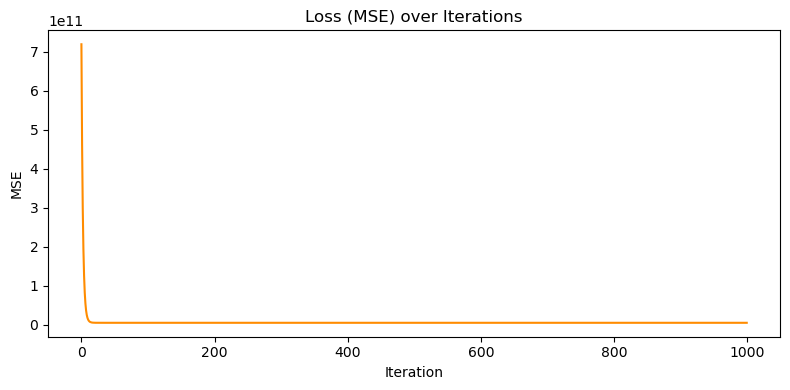

Initial loss: 719,381,852,230
Final loss:   4,969,530,097


In [20]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='darkorange')
plt.title('Loss (MSE) over Iterations')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

print(f'Initial loss: {model.loss_history[0]:,.0f}')
print(f'Final loss:   {model.loss_history[-1]:,.0f}')

## Step 12 — Evaluate the Model

We use two metrics:
- **MAE** (Mean Absolute Error): average dollar error in prediction
- **R² Score**: how well our model explains the variance in price (1 = perfect, 0 = no better than just using mean)

In [21]:
# Predict on test set
y_pred = model.predict(X_test_scaled)

# MAE
mae = np.mean(np.abs(y_pred - y_test))

# R² Score
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f'Mean Absolute Error (MAE): ${mae:,.0f}')
print(f'R² Score:                   {r2:.4f}')

Mean Absolute Error (MAE): $47,981
R² Score:                   0.9560


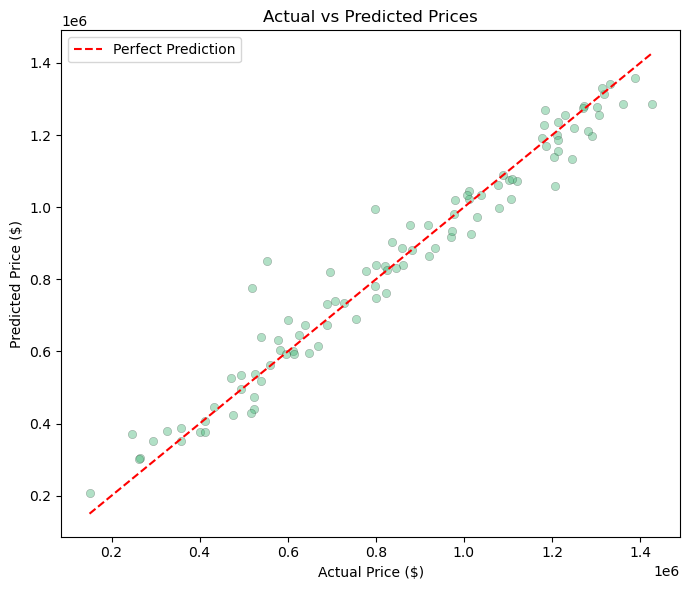

In [22]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='mediumseagreen', edgecolors='black', linewidths=0.3)
# Perfect prediction line
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

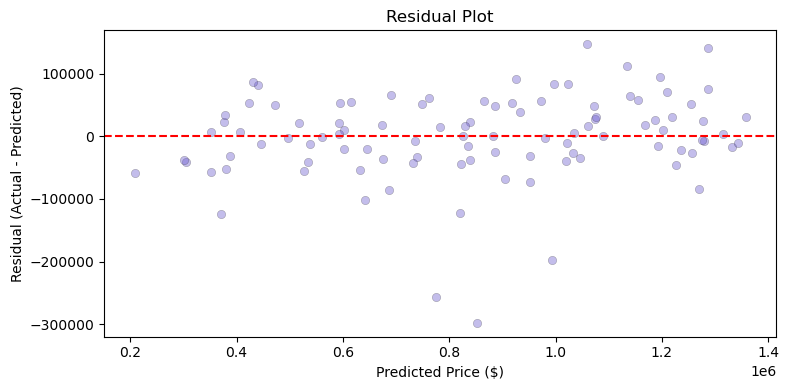

If residuals are randomly spread around 0 → model is good!


In [23]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.4, color='slateblue', edgecolors='black', linewidths=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

print('If residuals are randomly spread around 0 → model is good!')

## ✅ Summary

| Step | What we did |
|---|---|
| Data Loading | Loaded NYC Housing CSV |
| Null Analysis | Found and visualized missing values |
| Duplicate Detection | Found and removed duplicate rows |
| Preprocessing | Filled nulls with median |
| Correlation Analysis | Plotted feature correlation with price |
| Feature Selection | Chose SQFT, BATHS, BEDS, BUILDING_AGE |
| Train-Test Split | 80-20 manual split |
| Feature Scaling | Standardization (z-score) |
| Linear Regression | Built from scratch with Gradient Descent |
| Evaluation | MAE and R² score + visual plots |

> **Key takeaway:** SQFT (square footage) was the strongest predictor of housing price. Our model was built entirely with numpy and pandas — no sklearn needed!